In [1]:
# =============================================================================
# DAY 6 — BASELINE MODELS & EVALUATION
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Load train/test splits & quick audit
#   Task 2 — Why accuracy alone lies (the imbalanced data trap)
#   Task 3 — Logistic Regression baseline
#   Task 4 — Decision Tree baseline
#   Task 5 — Confusion matrix deep-dive
#   Task 6 — ROC-AUC curve comparison
#   Task 7 — Model comparison summary & save results
# =============================================================================
# LIBRARIES NEEDED — should already be installed from Day 5.
# If not: pip install scikit-learn
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import os
import warnings

warnings.filterwarnings("ignore")

# ── Plotting style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
})

# Colour palette (consistent with Days 3-5)
CLR_RETAIN = "#1D9E75"
CLR_CHURN  = "#E24B4A"
CLR_NEUT   = "#378ADD"
CLR_WARN   = "#F4A83A"
CLR_GREY   = "#9E9E9E"
CLR_PURPLE = "#9B59B6"

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = "C:/Users/white/Downloads/Learn/Churn_project/data"
VISUALS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/visuals"
OUTPUTS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/outputs"

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(VISUALS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("=" * 65)
print("  DAY 6 — BASELINE MODELS & EVALUATION")
print("=" * 65)

  DAY 6 — BASELINE MODELS & EVALUATION


In [2]:
# =============================================================================
# TASK 1 — LOAD TRAIN/TEST SPLITS & QUICK AUDIT
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 1 — Load train/test splits")
print("=" * 65)

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()  # DataFrame → Series
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print(f"\n  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,}  rows × {X_test.shape[1]} features")
print(f"  y_train churn rate : {y_train.mean()*100:.1f}%")
print(f"  y_test  churn rate : {y_test.mean()*100:.1f}%")
print("\n  Stratification confirmed ✓  (churn ratio ~equal in both splits)")

# ── Sanity check: no nulls ────────────────────────────────────────────────────
total_nulls = X_train.isnull().sum().sum() + X_test.isnull().sum().sum()
print(f"  Null values in X_train + X_test : {total_nulls}  ✓")

print("\n  Task 1 complete ✓")


  TASK 1 — Load train/test splits

  X_train : 5,634 rows × 39 features
  X_test  : 1,409  rows × 39 features
  y_train churn rate : 26.5%
  y_test  churn rate : 26.5%

  Stratification confirmed ✓  (churn ratio ~equal in both splits)
  Null values in X_train + X_test : 0  ✓

  Task 1 complete ✓



  TASK 2 — The imbalanced data trap

  Our dataset has ~26.5% churn (class 1) and ~73.5% retained (class 0).
  This is a class imbalance — and it creates a dangerous trap:

  THE "DUMB MODEL" THOUGHT EXPERIMENT
  ─────────────────────────────────────
  Imagine a model that ALWAYS predicts "No Churn" regardless of input.
  It never even looks at the features — it just says "retained" every time.

  How accurate would it be?

  Naive model accuracy = 73.5%  ← looks impressive!

  But this model catches ZERO churned customers.
  It's 100% useless for our actual goal.

  This is why we need multiple metrics:

  ┌─────────────────┬──────────────────────────────────────────────────────┐
  │ Metric          │ What it measures                                     │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ Accuracy        │ % of all predictions correct                         │
  │                 │ MISLEADING when classes are imbalanced               │
 

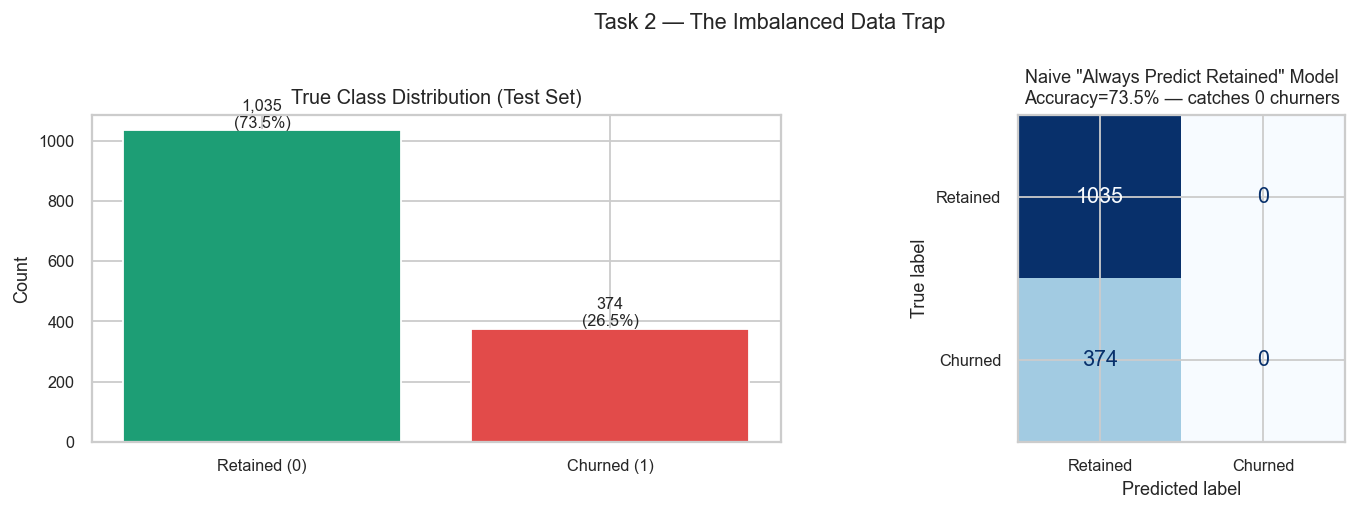

  Chart saved: day6_imbalanced_trap.png

  Task 2 complete ✓


In [3]:
# =============================================================================
# TASK 2 — WHY ACCURACY ALONE LIES (THE IMBALANCED DATA TRAP)
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 2 — The imbalanced data trap")
print("=" * 65)

print("""
  Our dataset has ~26.5% churn (class 1) and ~73.5% retained (class 0).
  This is a class imbalance — and it creates a dangerous trap:

  THE "DUMB MODEL" THOUGHT EXPERIMENT
  ─────────────────────────────────────
  Imagine a model that ALWAYS predicts "No Churn" regardless of input.
  It never even looks at the features — it just says "retained" every time.

  How accurate would it be?
""")

# Simulate a naive "always predict 0" classifier
y_naive = np.zeros(len(y_test), dtype=int)
naive_acc = accuracy_score(y_test, y_naive)

print(f"  Naive model accuracy = {naive_acc*100:.1f}%  ← looks impressive!")
print(f"""
  But this model catches ZERO churned customers.
  It's 100% useless for our actual goal.

  This is why we need multiple metrics:

  ┌─────────────────┬──────────────────────────────────────────────────────┐
  │ Metric          │ What it measures                                     │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ Accuracy        │ % of all predictions correct                         │
  │                 │ MISLEADING when classes are imbalanced               │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ Precision       │ Of predicted churners, how many actually churned?    │
  │                 │ "When we raise the alarm, are we usually right?"     │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ Recall          │ Of actual churners, how many did we catch?           │
  │                 │ "Did we miss any real churners?" ← MOST IMPORTANT    │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ F1 Score        │ Harmonic mean of Precision & Recall                  │
  │                 │ Balances both — good single summary metric           │
  ├─────────────────┼──────────────────────────────────────────────────────┤
  │ ROC-AUC         │ Model's ability to distinguish classes at all        │
  │                 │ thresholds — 0.5 = random, 1.0 = perfect            │
  └─────────────────┴──────────────────────────────────────────────────────┘

  For churn prediction, RECALL is king.
  A missed churner = lost revenue with zero chance to intervene.
  A false alarm = wasted retention offer (cheap by comparison).
""")

# Visualise the naive model failure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 2 — The Imbalanced Data Trap", fontsize=12)

# Left: class distribution
churn_counts = y_test.value_counts().sort_index()
axes[0].bar(["Retained (0)", "Churned (1)"], churn_counts.values,
            color=[CLR_RETAIN, CLR_CHURN], edgecolor="white")
axes[0].set_title("True Class Distribution (Test Set)", fontsize=11)
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    pct = v / len(y_test) * 100
    axes[0].text(i, v + 10, f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=9)

# Right: naive model "confusion"
cm_naive = confusion_matrix(y_test, y_naive)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_naive,
                              display_labels=["Retained", "Churned"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f'Naive "Always Predict Retained" Model\nAccuracy={naive_acc*100:.1f}% — catches 0 churners',
                  fontsize=10)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day6_imbalanced_trap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day6_imbalanced_trap.png")
print("\n  Task 2 complete ✓")

In [4]:
# =============================================================================
# TASK 3 — LOGISTIC REGRESSION BASELINE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 3 — Logistic Regression baseline")
print("=" * 65)

print("""
  What is Logistic Regression?
  ─────────────────────────────
  Despite the name, it's a CLASSIFICATION algorithm, not regression.
  It estimates the PROBABILITY that a customer belongs to class 1 (churned).

  How it works:
  • Takes a weighted sum of all features  →  Z = w1*x1 + w2*x2 + ... + b
  • Passes Z through a sigmoid function   →  P(churn) = 1 / (1 + e^(-Z))
  • Sigmoid squashes any number → range 0–1 (interpretable as probability)
  • Default decision boundary: if P(churn) ≥ 0.5 → predict "churned"

  Why start here?
  • Fast, interpretable, great baseline
  • Coefficients show the direction & strength of each feature's effect
  • Sets the performance floor — any complex model must beat this
""")

# ── 3a. Fit model with class_weight="balanced" ────────────────────────────────
# class_weight="balanced" automatically adjusts weights so the model pays
# MORE attention to the minority class (churned). This boosts recall.
lr_model = LogisticRegression(
    max_iter     = 1000,      # increase from default 100 to ensure convergence
    random_state = 42,
    class_weight = "balanced",
    solver       = "lbfgs"
)
lr_model.fit(X_train, y_train)
print("  Logistic Regression fitted ✓  (class_weight=balanced, max_iter=1000)")

# ── 3b. Predictions ───────────────────────────────────────────────────────────
y_pred_lr       = lr_model.predict(X_test)
y_prob_lr       = lr_model.predict_proba(X_test)[:, 1]  # probability of class 1

# ── 3c. Metrics ───────────────────────────────────────────────────────────────
lr_metrics = {
    "Accuracy"  : accuracy_score(y_test, y_pred_lr),
    "Precision" : precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall"    : recall_score(y_test, y_pred_lr, zero_division=0),
    "F1 Score"  : f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC"   : roc_auc_score(y_test, y_prob_lr),
}

print("\n" + "-" * 65)
print("  LOGISTIC REGRESSION — EVALUATION METRICS")
print("-" * 65)
for metric, value in lr_metrics.items():
    bar = "▮" * int(value * 30)
    print(f"  {metric:<12} : {value:.4f}  {bar}")

print("\n  Full classification report:")
print(classification_report(y_test, y_pred_lr, target_names=["Retained", "Churned"]))

# ── 3d. Top feature coefficients ─────────────────────────────────────────────
print("-" * 65)
print("  TOP 15 FEATURE COEFFICIENTS")
print("  (positive = pushes toward churn, negative = pushes toward retained)")
print("-" * 65)

coef_df = (
    pd.DataFrame({
        "Feature"     : X_train.columns,
        "Coefficient" : lr_model.coef_[0]
    })
    .sort_values("Coefficient", key=abs, ascending=False)
    .head(15)
    .reset_index(drop=True)
)

for _, row in coef_df.iterrows():
    direction = "→ churn risk ↑" if row["Coefficient"] > 0 else "→ churn risk ↓"
    bar = ("+" if row["Coefficient"] > 0 else "-") * int(abs(row["Coefficient"]) * 5)
    print(f"  {row['Feature']:<38} {row['Coefficient']:>+.4f}  {direction}")

print("\n  Task 3 complete ✓")


  TASK 3 — Logistic Regression baseline

  What is Logistic Regression?
  ─────────────────────────────
  Despite the name, it's a CLASSIFICATION algorithm, not regression.
  It estimates the PROBABILITY that a customer belongs to class 1 (churned).

  How it works:
  • Takes a weighted sum of all features  →  Z = w1*x1 + w2*x2 + ... + b
  • Passes Z through a sigmoid function   →  P(churn) = 1 / (1 + e^(-Z))
  • Sigmoid squashes any number → range 0–1 (interpretable as probability)
  • Default decision boundary: if P(churn) ≥ 0.5 → predict "churned"

  Why start here?
  • Fast, interpretable, great baseline
  • Coefficients show the direction & strength of each feature's effect
  • Sets the performance floor — any complex model must beat this

  Logistic Regression fitted ✓  (class_weight=balanced, max_iter=1000)

-----------------------------------------------------------------
  LOGISTIC REGRESSION — EVALUATION METRICS
---------------------------------------------------------------


  TASK 4 — Decision Tree baseline

  What is a Decision Tree?
  ─────────────────────────
  A tree-shaped sequence of if/else rules learned from the data.
  At each node it asks: "Which feature split best separates churned
  from retained?" — measured using Gini impurity or entropy.

  Example path a tree might learn:
    IF Contract = Month-to-month
      AND tenure < 6 months
        AND MonthlyCharges > $70
          → Predict: CHURNED  (high risk)

  Why use it as baseline?
  • Requires zero feature scaling (trees are scale-invariant)
  • Very interpretable — you can literally read the rules
  • Prone to overfitting if unconstrained, but a shallow tree is stable
  • Contrasts nicely with Logistic Regression (linear vs non-linear)

  Decision Tree fitted ✓  (max_depth=5, min_samples_leaf=20, balanced)
  Actual tree depth used : 5
  Number of leaves       : 31

-----------------------------------------------------------------
  DECISION TREE — EVALUATION METRICS
--------------------

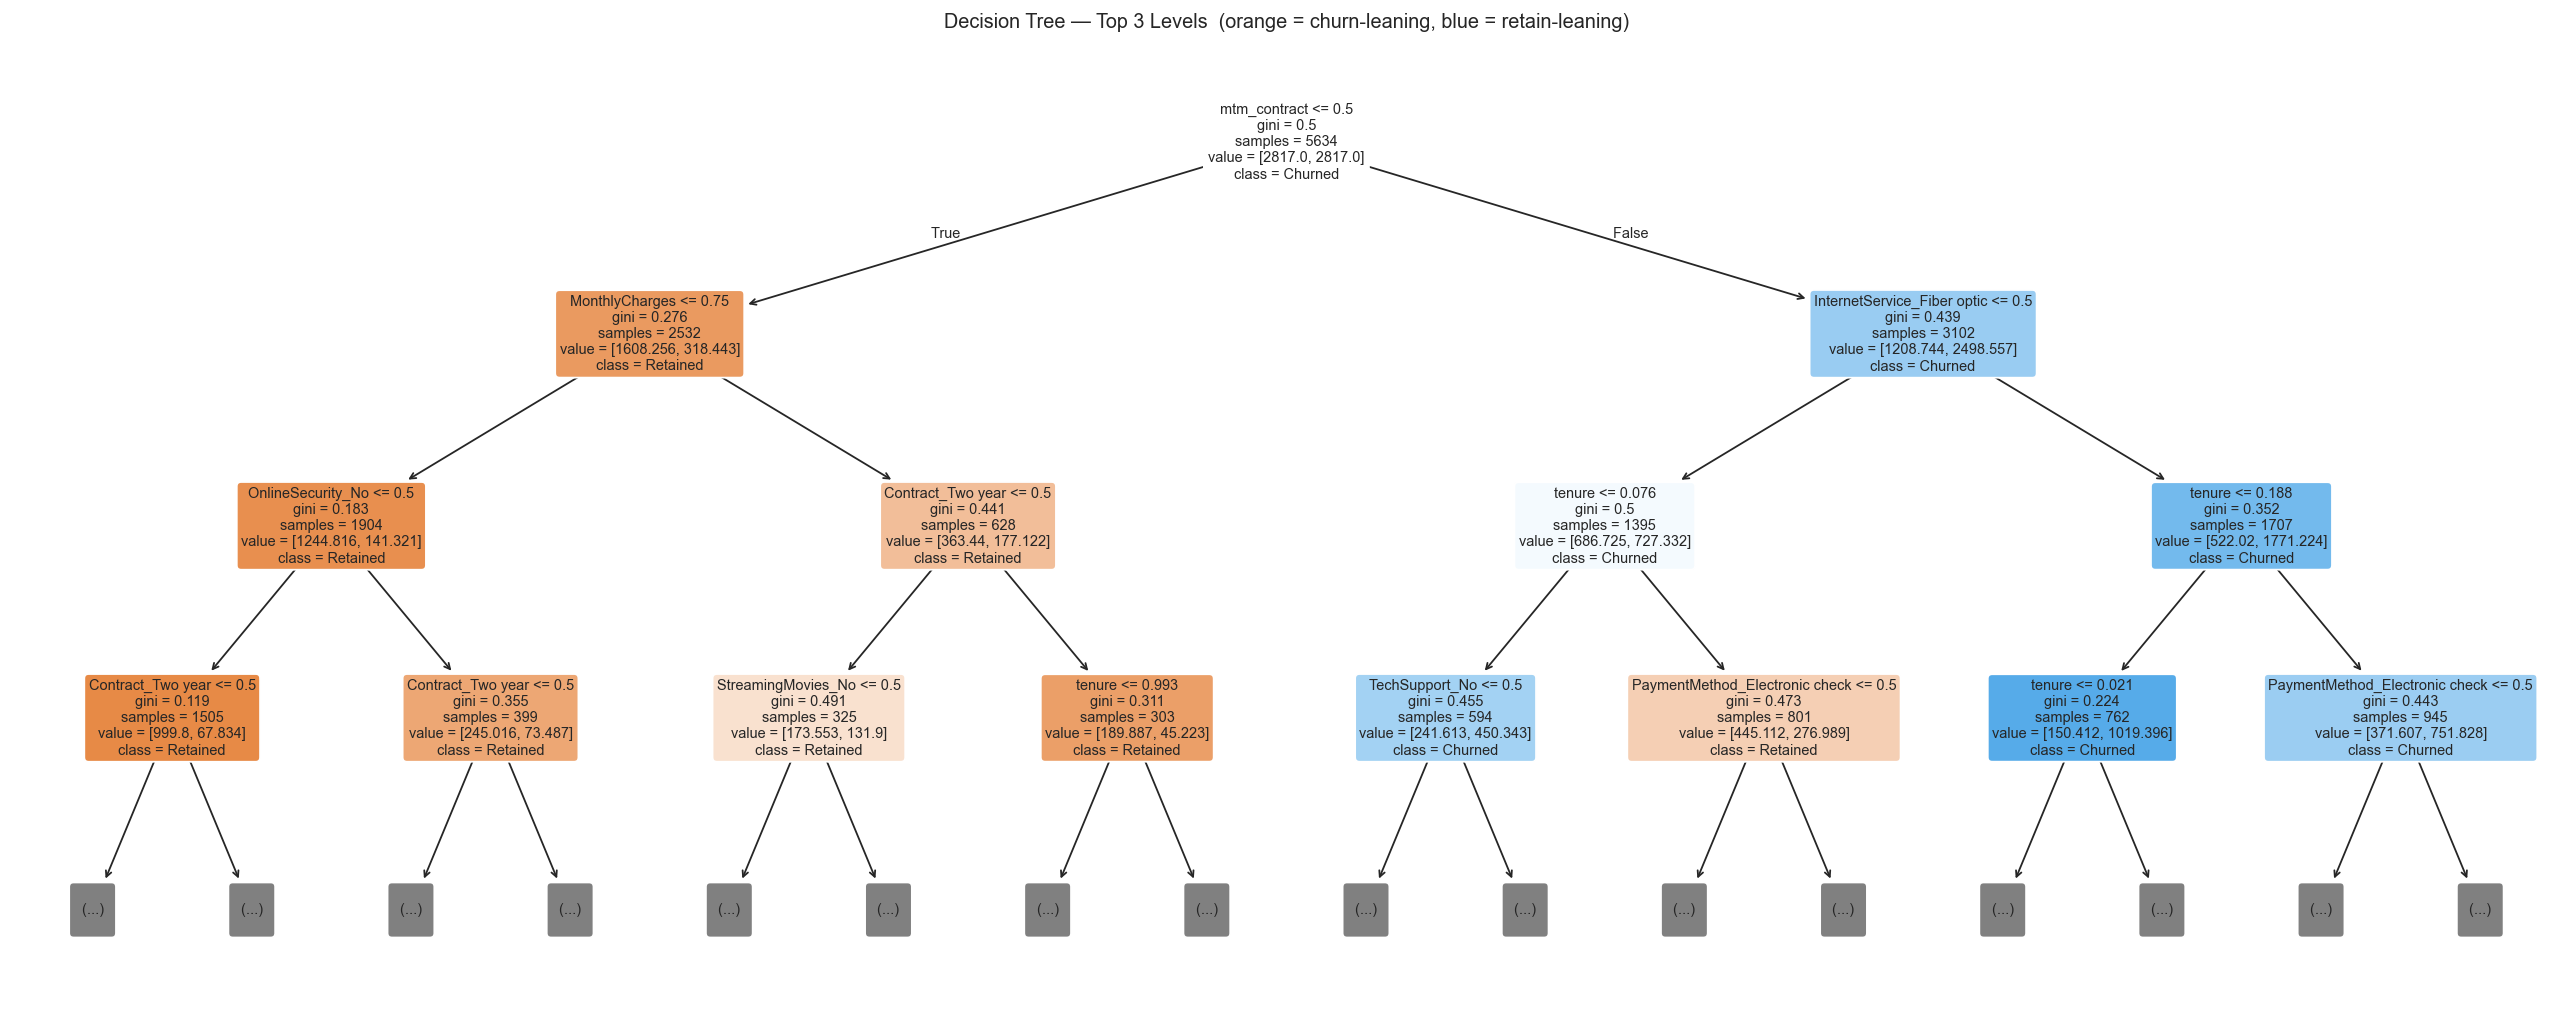


  Chart saved: day6_decision_tree.png

  Task 4 complete ✓


In [5]:
# =============================================================================
# TASK 4 — DECISION TREE BASELINE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 4 — Decision Tree baseline")
print("=" * 65)

print("""
  What is a Decision Tree?
  ─────────────────────────
  A tree-shaped sequence of if/else rules learned from the data.
  At each node it asks: "Which feature split best separates churned
  from retained?" — measured using Gini impurity or entropy.

  Example path a tree might learn:
    IF Contract = Month-to-month
      AND tenure < 6 months
        AND MonthlyCharges > $70
          → Predict: CHURNED  (high risk)

  Why use it as baseline?
  • Requires zero feature scaling (trees are scale-invariant)
  • Very interpretable — you can literally read the rules
  • Prone to overfitting if unconstrained, but a shallow tree is stable
  • Contrasts nicely with Logistic Regression (linear vs non-linear)
""")

# ── 4a. Fit a constrained tree (max_depth prevents overfitting) ───────────────
dt_model = DecisionTreeClassifier(
    max_depth    = 5,           # shallow tree = interpretable + generalises better
    min_samples_leaf = 20,      # leaf must represent at least 20 customers
    random_state = 42,
    class_weight = "balanced"
)
dt_model.fit(X_train, y_train)
print(f"  Decision Tree fitted ✓  (max_depth=5, min_samples_leaf=20, balanced)")
print(f"  Actual tree depth used : {dt_model.get_depth()}")
print(f"  Number of leaves       : {dt_model.get_n_leaves()}")

# ── 4b. Predictions ───────────────────────────────────────────────────────────
y_pred_dt  = dt_model.predict(X_test)
y_prob_dt  = dt_model.predict_proba(X_test)[:, 1]

# ── 4c. Metrics ───────────────────────────────────────────────────────────────
dt_metrics = {
    "Accuracy"  : accuracy_score(y_test, y_pred_dt),
    "Precision" : precision_score(y_test, y_pred_dt, zero_division=0),
    "Recall"    : recall_score(y_test, y_pred_dt, zero_division=0),
    "F1 Score"  : f1_score(y_test, y_pred_dt, zero_division=0),
    "ROC-AUC"   : roc_auc_score(y_test, y_prob_dt),
}

print("\n" + "-" * 65)
print("  DECISION TREE — EVALUATION METRICS")
print("-" * 65)
for metric, value in dt_metrics.items():
    bar = "▮" * int(value * 30)
    print(f"  {metric:<12} : {value:.4f}  {bar}")

print("\n  Full classification report:")
print(classification_report(y_test, y_pred_dt, target_names=["Retained", "Churned"]))

# ── 4d. Decision Tree visualisation (top 3 levels — readable) ────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names = X_train.columns.tolist(),
    class_names   = ["Retained", "Churned"],
    filled        = True,
    rounded       = True,
    max_depth     = 3,          # show top 3 levels only — stays readable
    fontsize      = 8,
    ax            = ax
)
ax.set_title("Decision Tree — Top 3 Levels  (orange = churn-leaning, blue = retain-leaning)",
             fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day6_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day6_decision_tree.png")
print("\n  Task 4 complete ✓")


  TASK 5 — Confusion matrix deep-dive

  Reading a Confusion Matrix
  ───────────────────────────
  A 2×2 grid of prediction outcomes:

                    PREDICTED
                  Retained  Churned
  ACTUAL Retained [  TN   |   FP  ]   TN = True Negative  (correctly said "stay")
         Churned  [  FN   |   TP  ]   TP = True Positive  (correctly caught churner)
                                       FP = False Positive (false alarm — predicted churn but stayed)
                                       FN = False Negative (MISSED churner — predicted stay but left)

  For churn prevention, FN is the COSTLIEST error.
  A missed churner = lost customer, lost revenue, zero intervention chance.
  FP is far cheaper — a wasted retention email or discount.



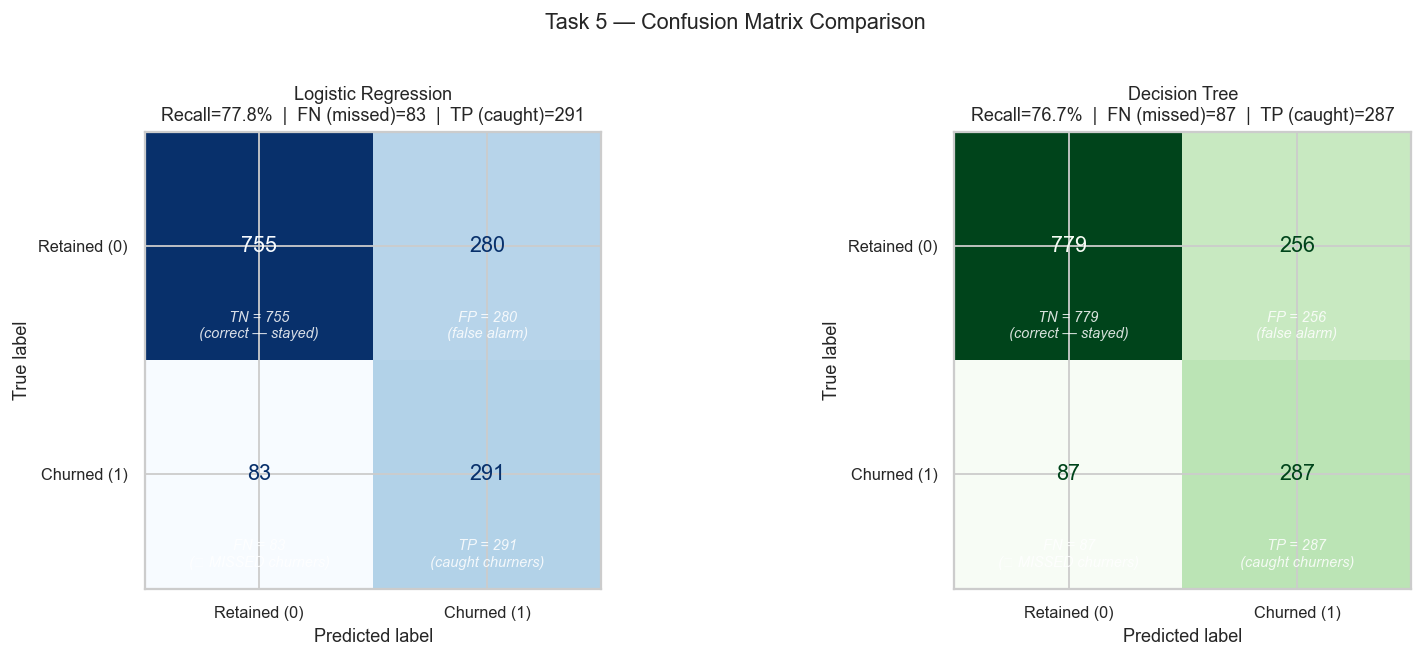

  Chart saved: day6_confusion_matrices.png

-----------------------------------------------------------------
  CONFUSION MATRIX BREAKDOWN
-----------------------------------------------------------------
  Metric                         Log. Reg   Dec. Tree
  ---------------------------- ----------  ----------
  True Positive  (caught churners)        291         287
  True Negative  (correct retains)        755         779
  False Positive (false alarms)        280         256
  False Negative (MISSED churners)         83          87 ← minimise this!

  Task 5 complete ✓


In [6]:
# =============================================================================
# TASK 5 — CONFUSION MATRIX DEEP-DIVE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 5 — Confusion matrix deep-dive")
print("=" * 65)

print("""
  Reading a Confusion Matrix
  ───────────────────────────
  A 2×2 grid of prediction outcomes:

                    PREDICTED
                  Retained  Churned
  ACTUAL Retained [  TN   |   FP  ]   TN = True Negative  (correctly said "stay")
         Churned  [  FN   |   TP  ]   TP = True Positive  (correctly caught churner)
                                       FP = False Positive (false alarm — predicted churn but stayed)
                                       FN = False Negative (MISSED churner — predicted stay but left)

  For churn prevention, FN is the COSTLIEST error.
  A missed churner = lost customer, lost revenue, zero intervention chance.
  FP is far cheaper — a wasted retention email or discount.
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 5 — Confusion Matrix Comparison", fontsize=12, y=1.01)

for ax, (model_name, y_pred, color) in zip(axes, [
    ("Logistic Regression", y_pred_lr, "Blues"),
    ("Decision Tree",       y_pred_dt, "Greens")
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Retained (0)", "Churned (1)"])
    disp.plot(ax=ax, colorbar=False, cmap=color)

    # Add TN / FP / FN / TP labels manually
    tn, fp, fn, tp = cm.ravel()
    labels = [
        (0, 0, f"TN = {tn:,}\n(correct — stayed)"),
        (0, 1, f"FP = {fp:,}\n(false alarm)"),
        (1, 0, f"FN = {fn:,}\n(⚠ MISSED churners)"),
        (1, 1, f"TP = {tp:,}\n(caught churners)"),
    ]
    for row, col, label in labels:
        ax.text(col, row + 0.35, label, ha="center", va="center",
                fontsize=8, color="white" if (row == col) else "white",
                style="italic", alpha=0.85)

    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.set_title(
        f"{model_name}\n"
        f"Recall={recall_val:.1%}  |  FN (missed)={fn:,}  |  TP (caught)={tp:,}",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day6_confusion_matrices.png")

# ── Numeric breakdown ─────────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  CONFUSION MATRIX BREAKDOWN")
print("-" * 65)
print(f"  {'Metric':<28} {'Log. Reg':>10}  {'Dec. Tree':>10}")
print(f"  {'-'*28} {'-'*10}  {'-'*10}")

for model_name, y_pred in [("Log. Reg", y_pred_lr), ("Dec. Tree", y_pred_dt)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

lr_tn, lr_fp, lr_fn, lr_tp = confusion_matrix(y_test, y_pred_lr).ravel()
dt_tn, dt_fp, dt_fn, dt_tp = confusion_matrix(y_test, y_pred_dt).ravel()

rows = [
    ("True Positive  (caught churners)", lr_tp, dt_tp),
    ("True Negative  (correct retains)", lr_tn, dt_tn),
    ("False Positive (false alarms)",    lr_fp, dt_fp),
    ("False Negative (MISSED churners)", lr_fn, dt_fn),
]
for label, lr_val, dt_val in rows:
    flag = " ← minimise this!" if "MISSED" in label else ""
    print(f"  {label:<28} {lr_val:>10,}  {dt_val:>10,}{flag}")

print("\n  Task 5 complete ✓")


  TASK 6 — ROC-AUC curve comparison

  What is the ROC Curve?
  ───────────────────────
  ROC = Receiver Operating Characteristic.
  It plots True Positive Rate (Recall) vs False Positive Rate
  at EVERY possible decision threshold (not just 0.5).

  Why is this useful?
  • Accuracy and F1 depend on the 0.5 threshold — arbitrary choice.
  • ROC curve shows the full trade-off across all thresholds.
  • AUC (Area Under Curve) summarises it in one number:
      0.5 = no better than random guessing
      0.7 = acceptable  |  0.8 = good  |  0.9+ = excellent

  The curve bowing toward the top-left corner = better model.



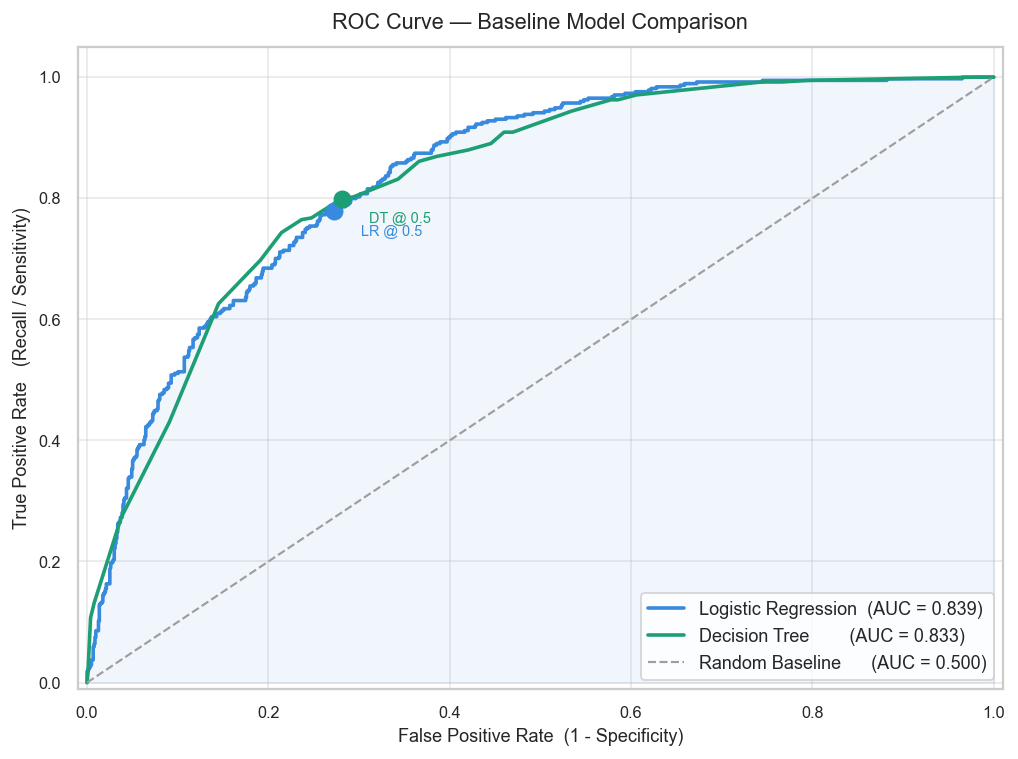

  Chart saved: day6_roc_curves.png

-----------------------------------------------------------------
  THRESHOLD ANALYSIS — Logistic Regression @ different cutoffs
  (default is 0.5 — lowering it catches more churners but adds false alarms)
-----------------------------------------------------------------
   Threshold   Precision    Recall        F1  Caught/Total churners
  ----------  ----------  --------  --------  ------------------------------
         0.3       0.430     0.928     0.588  347/374 (92.8%)
         0.4       0.469     0.861     0.607  322/374 (86.1%)
         0.5       0.510     0.778     0.616  291/374 (77.8%) ← default
         0.6       0.546     0.701     0.614  262/374 (70.1%)

  Key insight: lowering the threshold from 0.5 → 0.3 catches more churners
  (higher recall) but also increases false alarms (lower precision).
  The right threshold depends on the business cost of each error type.
  We'll revisit this in Day 8 when we tune the full model.

  Task 6 comp

In [7]:
# =============================================================================
# TASK 6 — ROC-AUC CURVE COMPARISON
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 6 — ROC-AUC curve comparison")
print("=" * 65)

print("""
  What is the ROC Curve?
  ───────────────────────
  ROC = Receiver Operating Characteristic.
  It plots True Positive Rate (Recall) vs False Positive Rate
  at EVERY possible decision threshold (not just 0.5).

  Why is this useful?
  • Accuracy and F1 depend on the 0.5 threshold — arbitrary choice.
  • ROC curve shows the full trade-off across all thresholds.
  • AUC (Area Under Curve) summarises it in one number:
      0.5 = no better than random guessing
      0.7 = acceptable  |  0.8 = good  |  0.9+ = excellent

  The curve bowing toward the top-left corner = better model.
""")

# ── 6a. Compute ROC curves ────────────────────────────────────────────────────
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# ── 6b. Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, color=CLR_NEUT,   lw=2,
        label=f"Logistic Regression  (AUC = {auc_lr:.3f})")
ax.plot(fpr_dt, tpr_dt, color=CLR_RETAIN, lw=2,
        label=f"Decision Tree        (AUC = {auc_dt:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_GREY, lw=1.2, ls="--",
        label="Random Baseline      (AUC = 0.500)")

# Shade the area under the LR curve
ax.fill_between(fpr_lr, tpr_lr, alpha=0.07, color=CLR_NEUT)

ax.set_title("ROC Curve — Baseline Model Comparison", fontsize=12, pad=10)
ax.set_xlabel("False Positive Rate  (1 - Specificity)")
ax.set_ylabel("True Positive Rate   (Recall / Sensitivity)")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.4)

# Annotate operating point at threshold=0.5
for model_name, fpr_arr, tpr_arr, thresh_arr, color in [
    ("LR @ 0.5", fpr_lr, tpr_lr, thresholds_lr, CLR_NEUT),
    ("DT @ 0.5", fpr_dt, tpr_dt, thresholds_dt, CLR_RETAIN),
]:
    idx = np.argmin(np.abs(thresh_arr - 0.5))
    ax.scatter(fpr_arr[idx], tpr_arr[idx], color=color, s=80, zorder=5)
    ax.annotate(model_name,
                xy=(fpr_arr[idx], tpr_arr[idx]),
                xytext=(fpr_arr[idx] + 0.03, tpr_arr[idx] - 0.04),
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day6_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day6_roc_curves.png")

# ── 6c. Threshold analysis — what if we lower the threshold? ─────────────────
print("\n" + "-" * 65)
print("  THRESHOLD ANALYSIS — Logistic Regression @ different cutoffs")
print("  (default is 0.5 — lowering it catches more churners but adds false alarms)")
print("-" * 65)
print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Caught/Total churners'}")
print(f"  {'-'*10}  {'-'*10}  {'-'*8}  {'-'*8}  {'-'*30}")

total_churners = (y_test == 1).sum()
for thresh in [0.3, 0.4, 0.5, 0.6]:
    y_thresh = (y_prob_lr >= thresh).astype(int)
    prec = precision_score(y_test, y_thresh, zero_division=0)
    rec  = recall_score(y_test, y_thresh, zero_division=0)
    f1   = f1_score(y_test, y_thresh, zero_division=0)
    caught = (y_thresh[y_test == 1] == 1).sum()
    marker = " ← default" if thresh == 0.5 else ""
    print(f"  {thresh:>10.1f}  {prec:>10.3f}  {rec:>8.3f}  {f1:>8.3f}  "
          f"{caught}/{total_churners} ({caught/total_churners*100:.1f}%){marker}")

print("""
  Key insight: lowering the threshold from 0.5 → 0.3 catches more churners
  (higher recall) but also increases false alarms (lower precision).
  The right threshold depends on the business cost of each error type.
  We'll revisit this in Day 8 when we tune the full model.
""")

print("  Task 6 complete ✓")


  TASK 7 — Model comparison summary

-----------------------------------------------------------------
  FULL METRICS COMPARISON TABLE
-----------------------------------------------------------------
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Naive Baseline         0.7346     0.0000  0.0000    0.0000   0.5000
Logistic Regression    0.7424     0.5096  0.7781    0.6159   0.8389
Decision Tree          0.7566     0.5285  0.7674    0.6260   0.8331


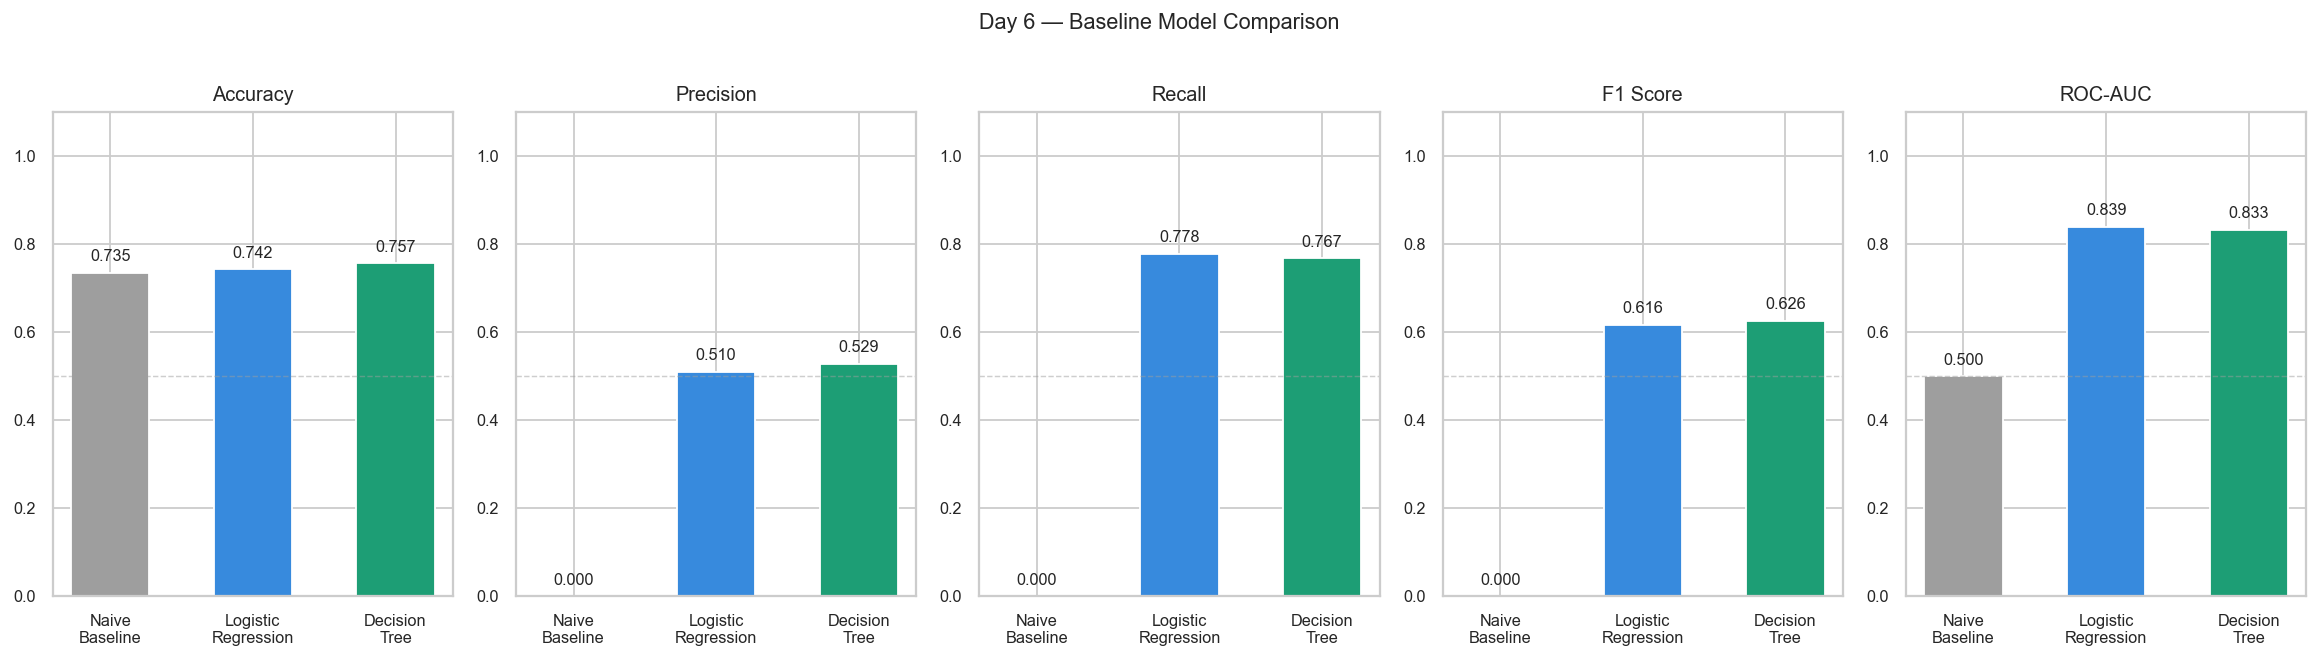

  Chart saved: day6_model_comparison.png

  Comparison table saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day6_model_comparison.csv

-----------------------------------------------------------------
  FINDINGS & INTERPRETATION
-----------------------------------------------------------------

  Logistic Regression vs Decision Tree:
  ──────────────────────────────────────
  • LR ROC-AUC  = 0.839  |  DT ROC-AUC = 0.833
    LR leads on AUC

  • LR Recall   = 0.778  |  DT Recall   = 0.767
    LR catches more churners

  • Both models far outperform the naive "always predict retained" baseline.

  Logistic Regression insights:
  • Interpretable coefficients show contract type and tenure as top drivers.
  • Good general-purpose baseline; linear boundary may miss complex patterns.

  Decision Tree insights:
  • Explicitly shows the IF/ELSE rules that predict churn.
  • Slightly lower AUC but highly explainable to non-technical stakeholders.
  • Can overfit on noisy features —

In [8]:
# =============================================================================
# TASK 7 — MODEL COMPARISON SUMMARY & SAVE RESULTS
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 7 — Model comparison summary")
print("=" * 65)

# ── 7a. Build comparison table ────────────────────────────────────────────────
naive_metrics = {
    "Accuracy"  : accuracy_score(y_test, y_naive),
    "Precision" : precision_score(y_test, y_naive, zero_division=0),
    "Recall"    : recall_score(y_test, y_naive, zero_division=0),
    "F1 Score"  : f1_score(y_test, y_naive, zero_division=0),
    "ROC-AUC"   : roc_auc_score(y_test, y_naive),
}

comparison = pd.DataFrame({
    "Naive Baseline"       : naive_metrics,
    "Logistic Regression"  : lr_metrics,
    "Decision Tree"        : dt_metrics,
}).T.round(4)

print("\n" + "-" * 65)
print("  FULL METRICS COMPARISON TABLE")
print("-" * 65)
print(comparison.to_string())

# ── 7b. Visual comparison chart ───────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
model_names     = ["Naive\nBaseline", "Logistic\nRegression", "Decision\nTree"]
model_colors    = [CLR_GREY, CLR_NEUT, CLR_RETAIN]
model_data      = [naive_metrics, lr_metrics, dt_metrics]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Day 6 — Baseline Model Comparison", fontsize=12, y=1.01)

for ax, metric in zip(axes, metrics_to_plot):
    values = [m[metric] for m in model_data]
    bars = ax.bar(model_names, values, color=model_colors, edgecolor="white", width=0.55)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color=CLR_GREY, lw=0.8, ls="--", alpha=0.5)
    for bar_obj, val in zip(bars, values):
        ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day6_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day6_model_comparison.png")

# ── 7c. Save comparison table to CSV ─────────────────────────────────────────
comparison.to_csv(f"{OUTPUTS_DIR}/day6_model_comparison.csv")
print(f"\n  Comparison table saved → {OUTPUTS_DIR}/day6_model_comparison.csv")

# ── 7d. Narrative summary ─────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  FINDINGS & INTERPRETATION")
print("-" * 65)
print(f"""
  Logistic Regression vs Decision Tree:
  ──────────────────────────────────────
  • LR ROC-AUC  = {auc_lr:.3f}  |  DT ROC-AUC = {auc_dt:.3f}
    {'LR leads on AUC' if auc_lr > auc_dt else 'DT leads on AUC'}

  • LR Recall   = {lr_metrics['Recall']:.3f}  |  DT Recall   = {dt_metrics['Recall']:.3f}
    {'LR catches more churners' if lr_metrics['Recall'] > dt_metrics['Recall'] else 'DT catches more churners'}

  • Both models far outperform the naive "always predict retained" baseline.

  Logistic Regression insights:
  • Interpretable coefficients show contract type and tenure as top drivers.
  • Good general-purpose baseline; linear boundary may miss complex patterns.

  Decision Tree insights:
  • Explicitly shows the IF/ELSE rules that predict churn.
  • Slightly lower AUC but highly explainable to non-technical stakeholders.
  • Can overfit on noisy features — depth constraint (max_depth=5) helps.

  Limitations of both:
  • These are unconstrained baselines — no hyperparameter tuning yet.
  • Day 8 will test Random Forest & XGBoost + GridSearchCV tuning,
    which will substantially improve on these numbers.
""")

In [9]:
# ── DAY 6 SUMMARY ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  DAY 6 COMPLETE — KEY FINDINGS")
print("=" * 65)
print(f"  Naive baseline accuracy  : {naive_metrics['Accuracy']*100:.1f}%  (useless — catches 0 churners)")
print(f"  Logistic Regression AUC  : {auc_lr:.3f}  |  Recall: {lr_metrics['Recall']:.3f}")
print(f"  Decision Tree AUC        : {auc_dt:.3f}  |  Recall: {dt_metrics['Recall']:.3f}")
print(f"  FN (missed churners)     : LR={lr_fn}  |  DT={dt_fn}")
print(f"  TP (caught churners)     : LR={lr_tp}  |  DT={dt_tp}")
print(f"  Best baseline so far     : {'Logistic Regression' if auc_lr >= auc_dt else 'Decision Tree'}")
print("")
print("  Charts saved (5 total):")
print("  -> day6_imbalanced_trap.png")
print("  -> day6_decision_tree.png")
print("  -> day6_confusion_matrices.png")
print("  -> day6_roc_curves.png")
print("  -> day6_model_comparison.png")
print("")
print("  TOMORROW — Day 7:")
print("  -> Cross-validation (K-Fold) — why a single train/test split isn't enough")
print("  -> Precision-Recall curve — better than ROC for imbalanced data")
print("  -> Hyperparameter tuning with GridSearchCV (LR + DT)")
print("  -> Learning curves — diagnose overfitting vs underfitting")
print("=" * 65)

  DAY 6 COMPLETE — KEY FINDINGS
  Naive baseline accuracy  : 73.5%  (useless — catches 0 churners)
  Logistic Regression AUC  : 0.839  |  Recall: 0.778
  Decision Tree AUC        : 0.833  |  Recall: 0.767
  FN (missed churners)     : LR=83  |  DT=87
  TP (caught churners)     : LR=291  |  DT=287
  Best baseline so far     : Logistic Regression

  Charts saved (5 total):
  -> day6_imbalanced_trap.png
  -> day6_decision_tree.png
  -> day6_confusion_matrices.png
  -> day6_roc_curves.png
  -> day6_model_comparison.png

  TOMORROW — Day 7:
  -> Cross-validation (K-Fold) — why a single train/test split isn't enough
  -> Precision-Recall curve — better than ROC for imbalanced data
  -> Hyperparameter tuning with GridSearchCV (LR + DT)
  -> Learning curves — diagnose overfitting vs underfitting
